In [16]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

In [5]:
df_tweets = pd.read_csv('data/tweets.csv')
df_users = pd.read_csv('data/users.csv')

In [8]:
df_tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203451 entries, 0 to 203450
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   user_id                195386 non-null  float64
 1   user_key               203451 non-null  object 
 2   created_at             203430 non-null  float64
 3   created_str            203430 non-null  object 
 4   retweet_count          58052 non-null   float64
 5   retweeted              58052 non-null   object 
 6   favorite_count         58052 non-null   float64
 7   text                   203430 non-null  object 
 8   tweet_id               201137 non-null  float64
 9   source                 58053 non-null   object 
 10  hashtags               203451 non-null  object 
 11  expanded_urls          203451 non-null  object 
 12  posted                 203451 non-null  object 
 13  mentions               203451 non-null  object 
 14  retweeted_status_id    39649 non-nul

In [9]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                392 non-null    float64
 1   location          284 non-null    object 
 2   name              383 non-null    object 
 3   followers_count   383 non-null    float64
 4   statuses_count    383 non-null    float64
 5   time_zone         368 non-null    object 
 6   verified          383 non-null    object 
 7   lang              383 non-null    object 
 8   screen_name       453 non-null    object 
 9   description       338 non-null    object 
 10  created_at        383 non-null    object 
 11  favourites_count  383 non-null    float64
 12  friends_count     383 non-null    float64
 13  listed_count      383 non-null    float64
dtypes: float64(6), object(8)
memory usage: 49.7+ KB


In [12]:
df_tweets["tweet_id"] = df_tweets["tweet_id"].astype("Int64")
df_tweets["user_id"] = df_tweets["user_id"].astype("Int64")
df_users["id"] = df_users["id"].astype("Int64")
df_tweets["created_at_dt"] = pd.to_datetime(df_tweets["created_str"], errors="coerce")

In [13]:
df = df_tweets.merge(
    df_users,
    left_on="user_key",
    right_on="screen_name",
    how="left"
)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203451 entries, 0 to 203450
Data columns (total 31 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                195386 non-null  Int64         
 1   user_key               203451 non-null  object        
 2   created_at_x           203430 non-null  float64       
 3   created_str            203430 non-null  object        
 4   retweet_count          58052 non-null   float64       
 5   retweeted              58052 non-null   object        
 6   favorite_count         58052 non-null   float64       
 7   text                   203430 non-null  object        
 8   tweet_id               201137 non-null  Int64         
 9   source                 58053 non-null   object        
 10  hashtags               203451 non-null  object        
 11  expanded_urls          203451 non-null  object        
 12  posted                 203451 non-null  obje

## Retweet network of users

In [17]:
# removing empty retweets
rt = df_tweets[df_tweets["retweeted_status_id"].notna()].copy()

In [25]:
rt["retweeter"] = rt["user_key"]
rt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39649 entries, 4 to 203444
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                39597 non-null  Int64         
 1   user_key               39649 non-null  object        
 2   created_at             39649 non-null  float64       
 3   created_str            39649 non-null  object        
 4   retweet_count          37973 non-null  float64       
 5   retweeted              37973 non-null  object        
 6   favorite_count         37973 non-null  float64       
 7   text                   39649 non-null  object        
 8   tweet_id               39649 non-null  Int64         
 9   source                 37973 non-null  object        
 10  hashtags               39649 non-null  object        
 11  expanded_urls          39649 non-null  object        
 12  posted                 39649 non-null  object        
 13  menti

In [27]:
# Build lookup: tweet_id -> user_key
tweet_to_user = (
    df_tweets
    .dropna(subset=["tweet_id"])
    .drop_duplicates(subset=["tweet_id"])
    .set_index("tweet_id")["user_key"]
)


print(tweet_to_user.head())

# Map retweeted tweet to original author
rt["original_author"] = rt["retweeted_status_id"].map(tweet_to_user)

tweet_id
836227891897651200          kathiemrr
765198948239810560     traceyhappymom
616002306572746752      evewebster373
776693302926147584        blacktolive
777594647875059712    jacquelinisbest
Name: user_key, dtype: object


In [29]:
rt["original_author"].isna().mean()

0.9411838886226639

In [30]:
rt = rt.dropna(subset=["original_author"])
rt = rt[rt["retweeter"] != rt["original_author"]]

In [32]:
# defining edges

edges = (
    rt
    .groupby(["retweeter", "original_author"])
    .size()
    .reset_index(name="weight")
)

In [34]:
edges

,retweeter,original_author,weight
0,_billy_moyer_,westernwindwes,1
1,_nickluna_,cookncooks,3
2,_nickluna_,emileewaren,1
3,_nickluna_,evagreen69,1
4,_nickluna_,garrettsimpson_,3
...,...,...,...
720,worldofhashtags,danageezus,16
721,worldofhashtags,dannythehappies,1
722,worldofhashtags,giselleevns,8
723,worldofhashtags,holycrapchrix,1


In [38]:
G = nx.DiGraph()

for _, row in edges.iterrows():
    G.add_edge(
        row["retweeter"],
        row["original_author"],
        weight=row["weight"]
    )

In [39]:
# pruning

MIN_WEIGHT = 3
G = nx.DiGraph(
    (u, v, d) for u, v, d in G.edges(data=True)
    if d["weight"] >= MIN_WEIGHT
)

In [41]:
# node attributes

user_attrs = (
    df_users
    .set_index("screen_name")
    [["followers_count", "friends_count", "statuses_count", "lang", "time_zone"]]
    .to_dict(orient="index")
)

nx.set_node_attributes(G, user_attrs)

In [43]:
# top 10 affected users

sorted(
    G.in_degree(weight="weight"),
    key=lambda x: x[1],
    reverse=True
)[:10]

[('ten_gop', 206),
 ('notritahart', 101),
 ('tpartynews', 95),
 ('giselleevns', 85),
 ('daileyjadon', 69),
 ('cassieweltch', 57),
 ('queenofthewo', 51),
 ('kathiemrr', 48),
 ('jasper_fly', 46),
 ('pamela_moore13', 46)]

In [44]:
# top 10 affecting users

sorted(
    G.out_degree(weight="weight"),
    key=lambda x: x[1],
    reverse=True
)[:10]

[('giselleevns', 134),
 ('melvinsroberts', 93),
 ('rightnpr', 84),
 ('realten_gop', 81),
 ('tpartynews', 71),
 ('puredavie', 54),
 ('traceyhappymom', 52),
 ('kathiemrr', 50),
 ('queenofthewo', 49),
 ('cassieweltch', 43)]

In [47]:
# centrality

pr = nx.pagerank(G, weight="weight")
nx.set_node_attributes(G, pr, "pagerank")

in_deg = dict(G.in_degree(weight="weight"))
nx.set_node_attributes(G, in_deg, "in_degree")

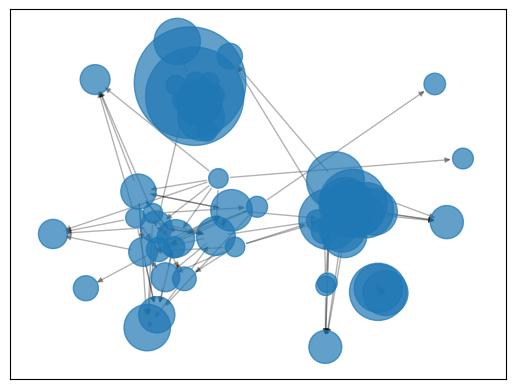

In [48]:
# sanity check

pos = nx.spring_layout(G, k=0.2, seed=42)

sizes = [G.nodes[n].get("pagerank", 0) * 50000 for n in G.nodes]

nx.draw_networkx_nodes(G, pos, node_size=sizes, alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.3, arrowsize=8)

In [49]:
nx.write_gexf(G, "retweet_network.gexf")

In [68]:
import community.community_louvain as community_louvain

undirected = G.to_undirected()
partition = community_louvain.best_partition(undirected)

nx.set_node_attributes(G, partition, "community")

In [70]:
from collections import Counter

Counter(partition.values())


Counter({3: 23, 0: 18, 1: 13, 2: 4, 4: 3})

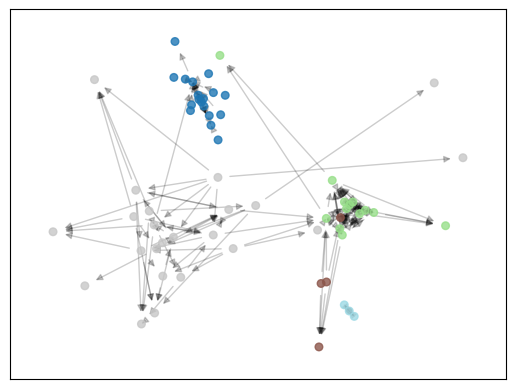

In [71]:
pos = nx.spring_layout(G, k=0.25, seed=42)

communities = [G.nodes[n]["community"] for n in G.nodes]
nx.draw_networkx_nodes(
    G, pos,
    node_color=communities,
    node_size=30,
    cmap=plt.cm.tab20,
    alpha=0.8
)

nx.draw_networkx_edges(G, pos, alpha=0.2)

### User community table

In [72]:
user_community = (
    pd.DataFrame.from_dict(partition, orient="index", columns=["community"])
    .reset_index()
    .rename(columns={"index": "screen_name"})
)

In [76]:
user_community.columns

Index(['screen_name', 'community', 'id_x', 'location_x', 'name_x',
       'followers_count_x', 'statuses_count_x', 'time_zone_x', 'verified_x',
       'lang_x', 'description_x', 'created_at_x', 'favourites_count_x',
       'friends_count_x', 'listed_count_x', 'id_y', 'location_y', 'name_y',
       'followers_count_y', 'statuses_count_y', 'time_zone_y', 'verified_y',
       'lang_y', 'description_y', 'created_at_y', 'favourites_count_y',
       'friends_count_y', 'listed_count_y'],
      dtype='object')

In [83]:
# Rename df_users columns (_y) to clean names
user_community = user_community.rename(columns={
    "lang_y": "lang",
    "time_zone_y": "time_zone",
    "followers_count_y": "followers_count",
    "friends_count_y": "friends_count",
    "statuses_count_y": "statuses_count",
    "location_y": "location",
    "description_y": "description"
})

# Drop all _x columns
user_community = user_community.drop(
    columns=[c for c in user_community.columns if c.endswith("_x")]
)

# Drop all columns ending with _y except the ones already renamed
cols_to_drop = [c for c in user_community.columns if c.endswith("_y")]
user_community = user_community.drop(columns=cols_to_drop)


In [84]:
user_community.columns

Index(['screen_name', 'community', 'id', 'location', 'name', 'followers_count',
       'statuses_count', 'time_zone', 'verified', 'lang', 'description',
       'created_at', 'favourites_count', 'friends_count', 'listed_count'],
      dtype='object')

In [87]:
# user metadata

df_tweets = df_tweets.merge(
    user_community[["screen_name", "community"]],
    left_on="user_key",
    right_on="screen_name",
    how="left"
)

In [103]:
df_tweets_in_comm = df_tweets[df_tweets["community"].notna()]
df_hashtags = df_tweets_in_comm.explode("hashtags_parsed")
df_hashtags = df_hashtags[df_hashtags["hashtags_parsed"].notna()]
df_hashtags[["user_key", "community", "hashtags_parsed"]].head(20)

,user_key,community,hashtags_parsed


In [104]:
df_hashtags.size

0

In [95]:
import ast

def parse_hashtags(s):
    if not s or s == "[]":
        return []
    try:
        # Convert string to list
        lst = ast.literal_eval(s)
        # Remove duplicates and normalize case
        return list({tag.lower() for tag in lst})
    except Exception:
        return []

# Apply to the column
df_tweets["hashtags_parsed"] = df_tweets["hashtags"].apply(parse_hashtags)

In [99]:
df_hashtags = df_tweets.explode("hashtags_parsed")
df_hashtags[["user_key", "community", "hashtags_parsed"]].head(20)

,user_key,community,hashtags_parsed
0,kathiemrr,1.0,NaN
1,traceyhappymom,1.0,NaN
2,evewebster373,NaN,NaN
3,blacktolive,NaN,NaN
4,jacquelinisbest,3.0,NaN
5,judelambertusa,3.0,NaN
6,carriethornthon,0.0,NaN
7,johnbranchh,NaN,NaN
8,march_for_trump,0.0,NaN
9,puredavie,1.0,NaN


### Community labels

In [111]:
# Keep only tweets from users in your network
df_tweets_in_comm = df_tweets[df_tweets["community"].notna()].copy()

# Merge to attach community (if not already merged)
df_tweets_in_comm = df_tweets_in_comm.merge(
    user_community[["screen_name", "community"]],
    left_on="user_key",
    right_on="screen_name",
    how="left"
)


In [112]:
# Some tweets have multiple URLs stored as a string representation of a list
import ast

def parse_urls(s):
    if not s or s == '[]':
        return []
    try:
        return ast.literal_eval(s)
    except Exception:
        return []

# Apply parser
df_tweets_in_comm["urls_parsed"] = df_tweets_in_comm["expanded_urls"].apply(parse_urls)

# Explode
df_urls = df_tweets_in_comm.explode("urls_parsed")

# Drop empty entries
df_urls = df_urls[df_urls["urls_parsed"].notna() & (df_urls["urls_parsed"] != '')]


In [113]:
# Keep community_y as 'community'
df_urls = df_urls.rename(columns={"community_y": "community"})

# Drop duplicate/unused columns
df_urls = df_urls.drop(columns=["community_x", "screen_name_x", "screen_name_y"])

In [114]:
top_urls = (
    df_urls
    .groupby("community")["urls_parsed"]
    .value_counts()
    .groupby(level=0)
    .head(10)  # top 10 URLs per community
)

print(top_urls)


community  urls_parsed                                                                                                                  
0          https://youtu.be/2_5b98GrlPE                                                                                                     136
           http://bit.ly/1O7pykd                                                                                                             53
           http://dailycaller.com/2014/08/14/allen-west-declares-obama-an-islamist/                                                          45
           http://www.frontpagemag.com/fpm/259172/communist-family-tree-valerie-jarrett-john-perazzo#.V91KgUuo9Nc.twitter                    40
           http://bit.ly/1Q6A95j                                                                                                             36
           https://twitter.com/hrtablaze/status/776888599300091904                                                                           36

In [115]:
top_urls_norm = (
    df_urls
    .dropna(subset=["community", "urls_parsed"])
    .groupby(["community", "urls_parsed"])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
)

print(top_urls_norm.head(20))


community  community  urls_parsed                                                                                                    
0          0          http://100percentfedup.com/breaking-exclusive-black-republican-fired-radio-station-spending-time-trump-detroit/    0.000060
                      http://21stcenturywire.com/2016/11/11/beyonce-jay-z-hillary-clinton-you-dont-represent-blacks-women/               0.000359
                      http://27x.net/6uhd                                                                                                0.000060
                      http://3tags.org/article/a-bold-proposal-for-conservative-gop-candidates                                           0.000060
                      http://3tags.org/article/gop-double-crossing-traitors                                                              0.000060
                      http://3tags.org/invite/bLk3                                                                                      

### Statistics

In [122]:
# In-degree and out-degree
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = dict(G.degree())  # ignores direction

# Average degrees
avg_in_degree = sum(in_degrees.values()) / G.number_of_nodes()
avg_out_degree = sum(out_degrees.values()) / G.number_of_nodes()
avg_total_degree = sum(total_degrees.values()) / G.number_of_nodes()

print("Average in-degree:", avg_in_degree)
print("Average out-degree:", avg_out_degree)
print("Average total degree:", avg_total_degree)

deg_values = list(total_degrees.values())
print("Degree stats:")
print("Min:", np.min(deg_values))
print("Max:", np.max(deg_values))
print("Median:", np.median(deg_values))
print("Mean:", np.mean(deg_values))

# Convert to undirected for clustering
G_undirected = G.to_undirected()

# Average clustering coefficient
avg_clustering = nx.average_clustering(G_undirected)
print("Average clustering coefficient:", avg_clustering)

# Degree assortativity (undirected)
degree_assortativity = nx.degree_assortativity_coefficient(G_undirected)
print("Degree assortativity:", degree_assortativity)

# Optional: in-degree vs out-degree correlation
in_out_assortativity = nx.degree_pearson_correlation_coefficient(G, x='in', y='out')
print("In-degree / out-degree correlation:", in_out_assortativity)

density = nx.density(G)
print("Network density:", density)

# Weakly connected components
num_wcc = nx.number_weakly_connected_components(G)
largest_wcc = max(nx.weakly_connected_components(G), key=len)
print("Number of weakly connected components:", num_wcc)
print("Size of largest WCC:", len(largest_wcc))

# Weighted PageRank
pagerank = nx.pagerank(G, weight='weight')
# Weighted in-degree centrality
in_deg_cent = dict(G.in_degree(weight='weight'))
# Weighted out-degree centrality
out_deg_cent = dict(G.out_degree(weight='weight'))

# Example: top 5 nodes by PageRank
top_pr = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 nodes by PageRank:", top_pr)


Average in-degree: 3.3278688524590163
Average out-degree: 3.3278688524590163
Average total degree: 6.655737704918033
Degree stats:
Min: 1
Max: 23
Median: 5.0
Mean: 6.655737704918033
Average clustering coefficient: 0.45802741050926604
Degree assortativity: -0.0748699031684348
In-degree / out-degree correlation: 0.4579275254218116
Network density: 0.05546448087431694
Number of weakly connected components: 2
Size of largest WCC: 58
Top 5 nodes by PageRank: [('ten_gop', 0.1290448600065996), ('tpartynews', 0.09997997330831576), ('notritahart', 0.04775050852617005), ('giselleevns', 0.03826917101404756), ('daileyjadon', 0.03461126744323938)]


Number of weakly connected components: 2 → network is almost fully connected; only one very small isolated component exists.

Size of largest WCC: 58 → most users form a single cohesive retweet cluster.

Network density: 0.055 → very sparse; only ~5.5% of all possible user-to-user connections exist. Typical of social media networks.

Average in-degree = 3.33, average out-degree = 3.33, average total degree = 6.66 → on average, each user retweets ~3 others and is retweeted by ~3 others.

Min/Max degrees: 1 → 23; Median: 5 → there are a few “hub” accounts with many retweets, but most nodes have moderate activity.

In/out-degree correlation = 0.46 → users who retweet a lot tend to get retweeted more, but it’s not perfect.

Average clustering coefficient = 0.458 → relatively high; users tend to form tight retweet triangles. This shows clusters of amplification.

Degree assortativity = -0.075 → slightly disassortative; high-degree users tend to connect to lower-degree users rather than other hubs.

Typical for troll/amplification networks: a few central accounts are retweeted by many small amplifiers.

Top nodes by PageRank: ten_gop, tpartynews, notritahart, giselleevns, daileyjadon → these are amplification hubs, likely controlling most of the retweet flow.

PageRank values show ten_gop alone accounts for ~13% of network influence, indicating high centralization.

### Visualizations

In [123]:
# Use the undirected version for layout
G_undirected = G.to_undirected()

# Position nodes with spring layout
pos = nx.spring_layout(G_undirected, seed=42, k=0.5)

# Node size based on PageRank
pagerank = nx.pagerank(G)
node_sizes = [v * 1000 for v in pagerank.values()]  # scale for plotting

# Node color based on community
communities = nx.get_node_attributes(G, 'community')
node_colors = [communities.get(n, -1) for n in G.nodes()]  # -1 if no community


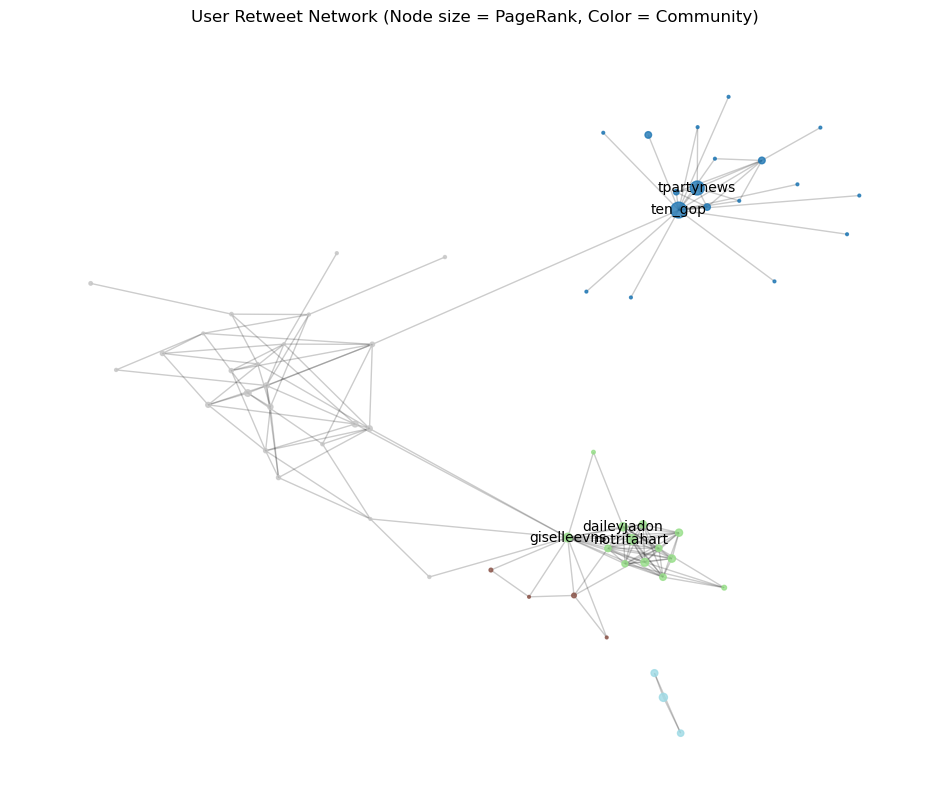

In [124]:
plt.figure(figsize=(12, 10))

# Draw nodes
nx.draw_networkx_nodes(
    G_undirected, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.tab20,
    alpha=0.8
)

# Draw edges
nx.draw_networkx_edges(G_undirected, pos, alpha=0.2)

# Optionally, draw labels for top hubs
top_nodes = [n for n, _ in sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:5]]
nx.draw_networkx_labels(G_undirected, pos, labels={n: n for n in top_nodes}, font_size=10)

plt.title("User Retweet Network (Node size = PageRank, Color = Community)")
plt.axis("off")
plt.show()


In [125]:
len(G)

61